<a href="https://colab.research.google.com/github/Doyinakinloye/DCP-predictive-maintenance-Project/blob/main/NASA_C_MAPSS_Pred_Maint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive maintenance using the NASA C-MAPSS Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import helper function
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys, calculate_results

--2026-07-28 19:58:48--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0.001s  

2026-07-28 19:58:48 (9.36 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
# import the csv files
rul_df = pd.read_csv("/content/drive/MyDrive/NASA Turbofan Predictive Maintenance/RUL_FD003.csv")
train_df = pd.read_csv("/content/drive/MyDrive/NASA Turbofan Predictive Maintenance/train_FD003.csv")
test_df = pd.read_csv("/content/drive/MyDrive/NASA Turbofan Predictive Maintenance/test_FD003.csv")

**Note**: Drop the column with constant values so as to remove noise from our data set

In [4]:
CONSTANT_SENSORS = []
for col in train_df.columns:
    if train_df[col].nunique() < 18:
        CONSTANT_SENSORS.append(col)

In [5]:
CONSTANT_SENSORS.remove("op_setting_2")
CONSTANT_SENSORS

['op_setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_6',
 'sensor_10',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19']

In [6]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
sensor_cols

['sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [7]:
# Get the sensors with varying values
USEFUL_SENSORS = [c for c in sensor_cols if c not in CONSTANT_SENSORS]
USEFUL_SENSORS

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_20',
 'sensor_21']

In [8]:
CEMENT_MAP = {
    'sensor_2':  'Preheater_Inlet_Temp',
    'sensor_3':  'Kiln_Burn_Zone_Temp',
    'sensor_4':  'Kiln_Outlet_Gas_Temp',
    'sensor_7':  'Mill_Diff_Press',
    'sensor_8':  'Crusher_Mill_Speed',
    'sensor_9':  'Separator_Fan_Speed',
    'sensor_11': 'ID_Fan_Kiln_Draft',
    'sensor_12': 'Fuel_Coal_Ratio',
    'sensor_13': 'Corrected_Mill_Speed',
    'sensor_14': 'Corrected_Separator_Speed',
    'sensor_15': 'Air_Split_Ratio',
    'sensor_20': 'Clinker_Cooler_Air_1',
    'sensor_21': 'Clinker_Cooler_Air_2',
}

In [9]:
train_df = train_df.rename(columns=CEMENT_MAP)
test_df = test_df.rename(columns=CEMENT_MAP)

In [10]:
# drop the constant columns
train_df = train_df.drop(CONSTANT_SENSORS, axis=1)
test_df = test_df.drop(CONSTANT_SENSORS, axis=1)

In [11]:
SENSOR_COLS = [CEMENT_MAP.get(c, c) for c in USEFUL_SENSORS]
SENSOR_COLS

['Preheater_Inlet_Temp',
 'Kiln_Burn_Zone_Temp',
 'Kiln_Outlet_Gas_Temp',
 'Mill_Diff_Press',
 'Crusher_Mill_Speed',
 'Separator_Fan_Speed',
 'ID_Fan_Kiln_Draft',
 'Fuel_Coal_Ratio',
 'Corrected_Mill_Speed',
 'Corrected_Separator_Speed',
 'Air_Split_Ratio',
 'Clinker_Cooler_Air_1',
 'Clinker_Cooler_Air_2']

Successfully removed all columns with little to zero variance and mapped our sensor columns with values that suit the competition

In [12]:
# merge RUL with the training set
max_cycle = train_df.groupby('unit_number')['time_cycle'].max().rename('max_cycle')
train_df = train_df.merge(max_cycle, left_on='unit_number', right_index=True)
train_df["RUL"] = train_df["max_cycle"] - train_df["time_cycle"]
train_df.drop('max_cycle', axis=1, inplace=True)

Visualize! Visualize! Visualize!

In [13]:
print("Asset lifetime (cycles to failure) — training set:")
print(train_df.groupby('unit_number')['RUL'].max().describe())

Asset lifetime (cycles to failure) — training set:
count    100.00000
mean     246.20000
std       86.48384
min      144.00000
25%      188.75000
50%      219.50000
75%      278.75000
max      524.00000
Name: RUL, dtype: float64


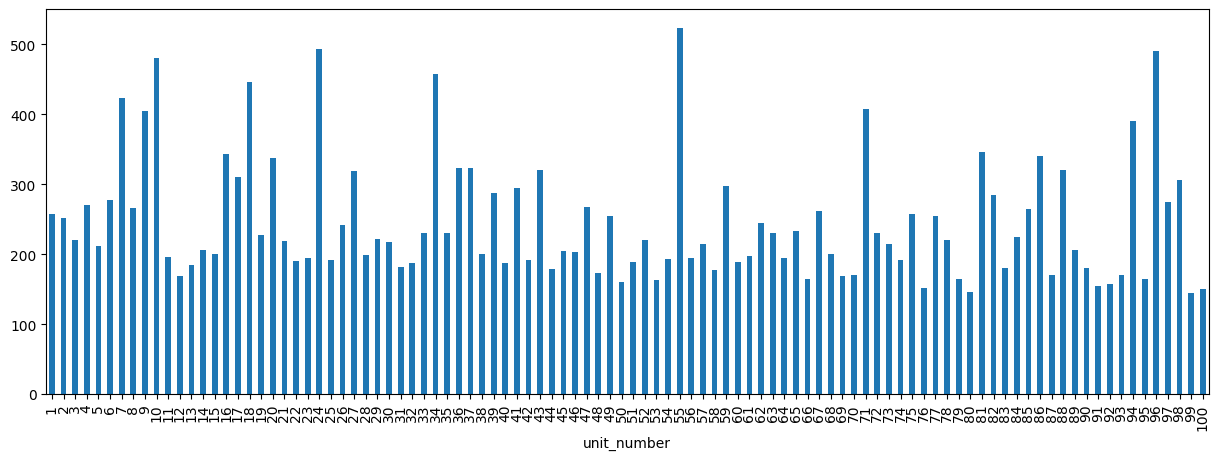

In [ ]:
train_df.groupby("unit_number")["RUL"].max().plot(kind="bar", figsize=(15, 5));

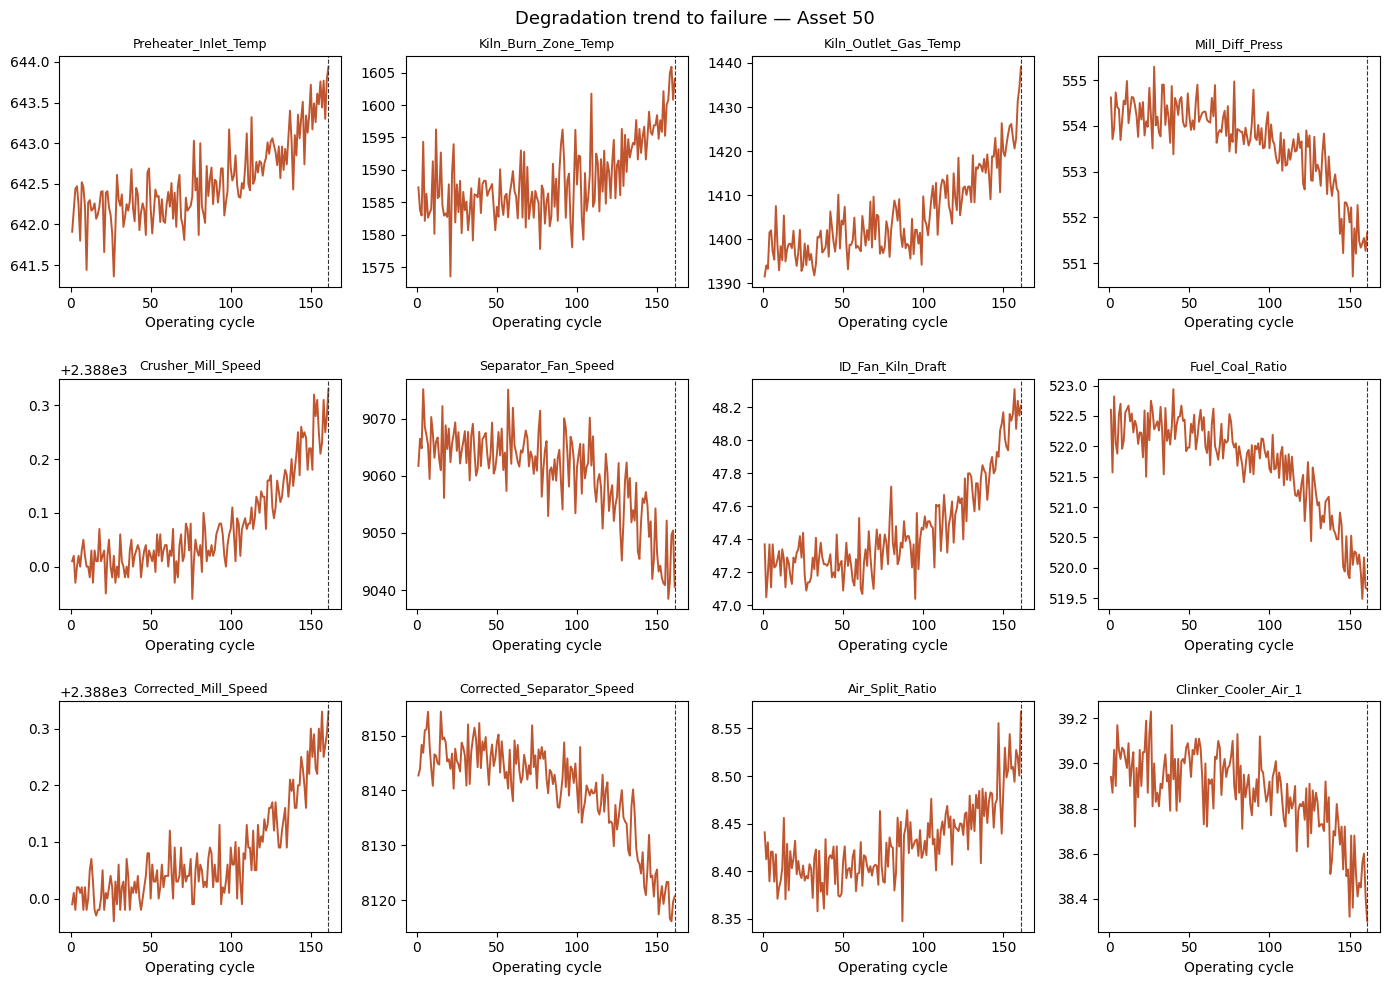

In [ ]:
# Degradation trend for a sample asset — do sensors drift as failure approaches?
sample_unit = 50
sample = train_df[train_df['unit_number'] == sample_unit]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, sname in zip(axes.flat, SENSOR_COLS[:12]):
    ax.plot(sample['time_cycle'], sample[sname], color='#c0562f', linewidth=1.4)
    ax.set_title(sname, fontsize=9)
    ax.set_xlabel('Operating cycle')
    ax.axvline(sample['time_cycle'].max(), color='#333333', linestyle='--', linewidth=0.8)
fig.suptitle(f"Degradation trend to failure — Asset {sample_unit}", fontsize=13)
plt.tight_layout()
plt.savefig('eda_degradation_trends.png', dpi=130)
plt.show()

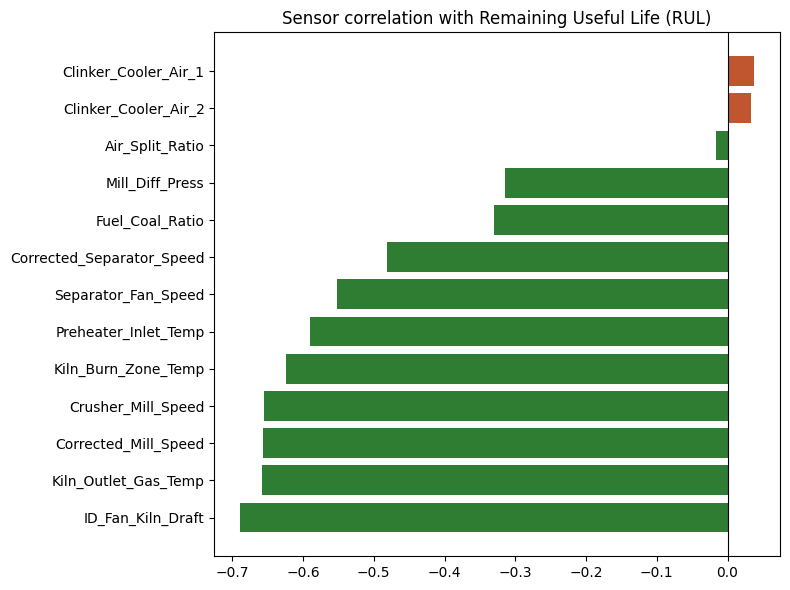

In [ ]:
# Sensor correlation with RUL — which signals matter most?
corr = train_df[SENSOR_COLS + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2e7d32' if v < 0 else '#c0562f' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_title('Sensor correlation with Remaining Useful Life (RUL)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('eda_sensor_rul_correlation.png', dpi=130)
plt.show()

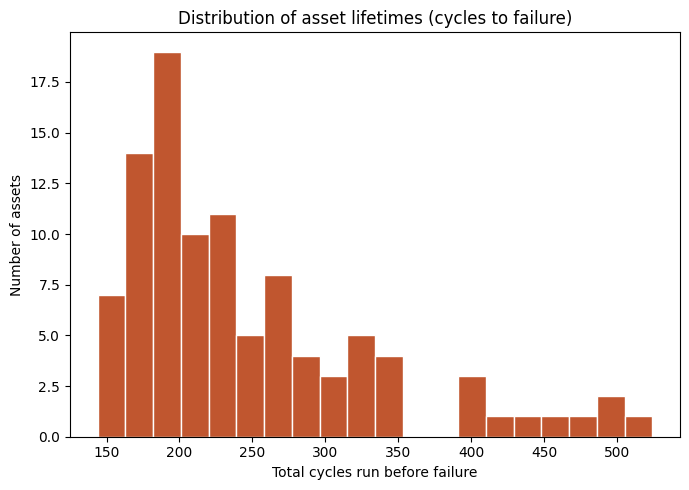

In [ ]:
# Asset lifetime distribution
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(train_df.groupby('unit_number')['RUL'].max(), bins=20, color='#c0562f', edgecolor='white')
ax.set_title('Distribution of asset lifetimes (cycles to failure)')
ax.set_xlabel('Total cycles run before failure')
ax.set_ylabel('Number of assets')
plt.tight_layout()
plt.savefig('eda_lifetime_distribution.png', dpi=130)
plt.show()

In [14]:
max = train_df.groupby("unit_number")["RUL"].max()
max_mean = max.median()
max_mean

219.5

### Calculate the Rolling Mean and Rolling STD for each column

In [15]:
WINDOW = 10

def add_rolling_feature(df, features, window=WINDOW):
  """This functions creates a rolling mean and std  column for each feature"""
  df = df.copy()
  for s in features:
    grp = df.groupby("unit_number")[s]
    df[f"{s}_rolling_mean"] = grp.transform(lambda x: x.rolling(window, min_periods=1).mean())
    df[f"{s}_rolling_std"] = grp.transform(lambda x: x.rolling(window, min_periods=1).std())
    baseline = grp.transform(lambda x: x.iloc[:5].mean())
    df[f"{s}_dev_from_baseline"] = df[s] - baseline
  return df

train_feat = add_rolling_feature(train_df, SENSOR_COLS)
test_feat = add_rolling_feature(test_df, SENSOR_COLS)

In [16]:
feature_cols = [c for c in train_feat.columns if any(
    c.endswith(sfx) for sfx in ['_rolling_mean', '_rolling_std', '_dev_from_baseline'])]

feature_cols

['Preheater_Inlet_Temp_rolling_mean',
 'Preheater_Inlet_Temp_rolling_std',
 'Preheater_Inlet_Temp_dev_from_baseline',
 'Kiln_Burn_Zone_Temp_rolling_mean',
 'Kiln_Burn_Zone_Temp_rolling_std',
 'Kiln_Burn_Zone_Temp_dev_from_baseline',
 'Kiln_Outlet_Gas_Temp_rolling_mean',
 'Kiln_Outlet_Gas_Temp_rolling_std',
 'Kiln_Outlet_Gas_Temp_dev_from_baseline',
 'Mill_Diff_Press_rolling_mean',
 'Mill_Diff_Press_rolling_std',
 'Mill_Diff_Press_dev_from_baseline',
 'Crusher_Mill_Speed_rolling_mean',
 'Crusher_Mill_Speed_rolling_std',
 'Crusher_Mill_Speed_dev_from_baseline',
 'Separator_Fan_Speed_rolling_mean',
 'Separator_Fan_Speed_rolling_std',
 'Separator_Fan_Speed_dev_from_baseline',
 'ID_Fan_Kiln_Draft_rolling_mean',
 'ID_Fan_Kiln_Draft_rolling_std',
 'ID_Fan_Kiln_Draft_dev_from_baseline',
 'Fuel_Coal_Ratio_rolling_mean',
 'Fuel_Coal_Ratio_rolling_std',
 'Fuel_Coal_Ratio_dev_from_baseline',
 'Corrected_Mill_Speed_rolling_mean',
 'Corrected_Mill_Speed_rolling_std',
 'Corrected_Mill_Speed_dev_from_

The std value shave some NaN Values so i would fill it

In [ ]:
for col in feature_cols:
    train_feat[col].fillna(method='bfill', inplace=True)
    test_feat[col].fillna(method='bfill', inplace=True)

In [ ]:
train_feat.isna().sum()

In [ ]:
test_feat.isna().sum()

### Outlier detection and removal

In [ ]:
from scipy import stats
z_scores = train_feat.groupby("unit_number")[SENSOR_COLS].transform(stats.zscore)
outliers = (abs(z_scores) > 3).sum(axis=0)
print(outliers)

Preheater_Inlet_Temp         114
Kiln_Burn_Zone_Temp          130
Kiln_Outlet_Gas_Temp         177
Mill_Diff_Press              249
Crusher_Mill_Speed           225
Separator_Fan_Speed          266
ID_Fan_Kiln_Draft            208
Fuel_Coal_Ratio              248
Corrected_Mill_Speed         237
Corrected_Separator_Speed    245
Air_Split_Ratio              128
Clinker_Cooler_Air_1         130
Clinker_Cooler_Air_2         123
dtype: int64


In [ ]:
from scipy import stats
z_scores2 = train_feat.groupby("unit_number")[feature_cols].transform(stats.zscore)
outliers2 = (abs(z_scores2) > 3).sum(axis=0)
print(outliers2)

Preheater_Inlet_Temp_rolling_mean              170
Preheater_Inlet_Temp_rolling_std               116
Preheater_Inlet_Temp_dev_from_baseline         114
Kiln_Burn_Zone_Temp_rolling_mean               197
Kiln_Burn_Zone_Temp_rolling_std                109
Kiln_Burn_Zone_Temp_dev_from_baseline          130
Kiln_Outlet_Gas_Temp_rolling_mean              234
Kiln_Outlet_Gas_Temp_rolling_std               102
Kiln_Outlet_Gas_Temp_dev_from_baseline         177
Mill_Diff_Press_rolling_mean                   235
Mill_Diff_Press_rolling_std                    179
Mill_Diff_Press_dev_from_baseline              249
Crusher_Mill_Speed_rolling_mean                221
Crusher_Mill_Speed_rolling_std                 141
Crusher_Mill_Speed_dev_from_baseline           225
Separator_Fan_Speed_rolling_mean               286
Separator_Fan_Speed_rolling_std                176
Separator_Fan_Speed_dev_from_baseline          266
ID_Fan_Kiln_Draft_rolling_mean                 260
ID_Fan_Kiln_Draft_rolling_std  

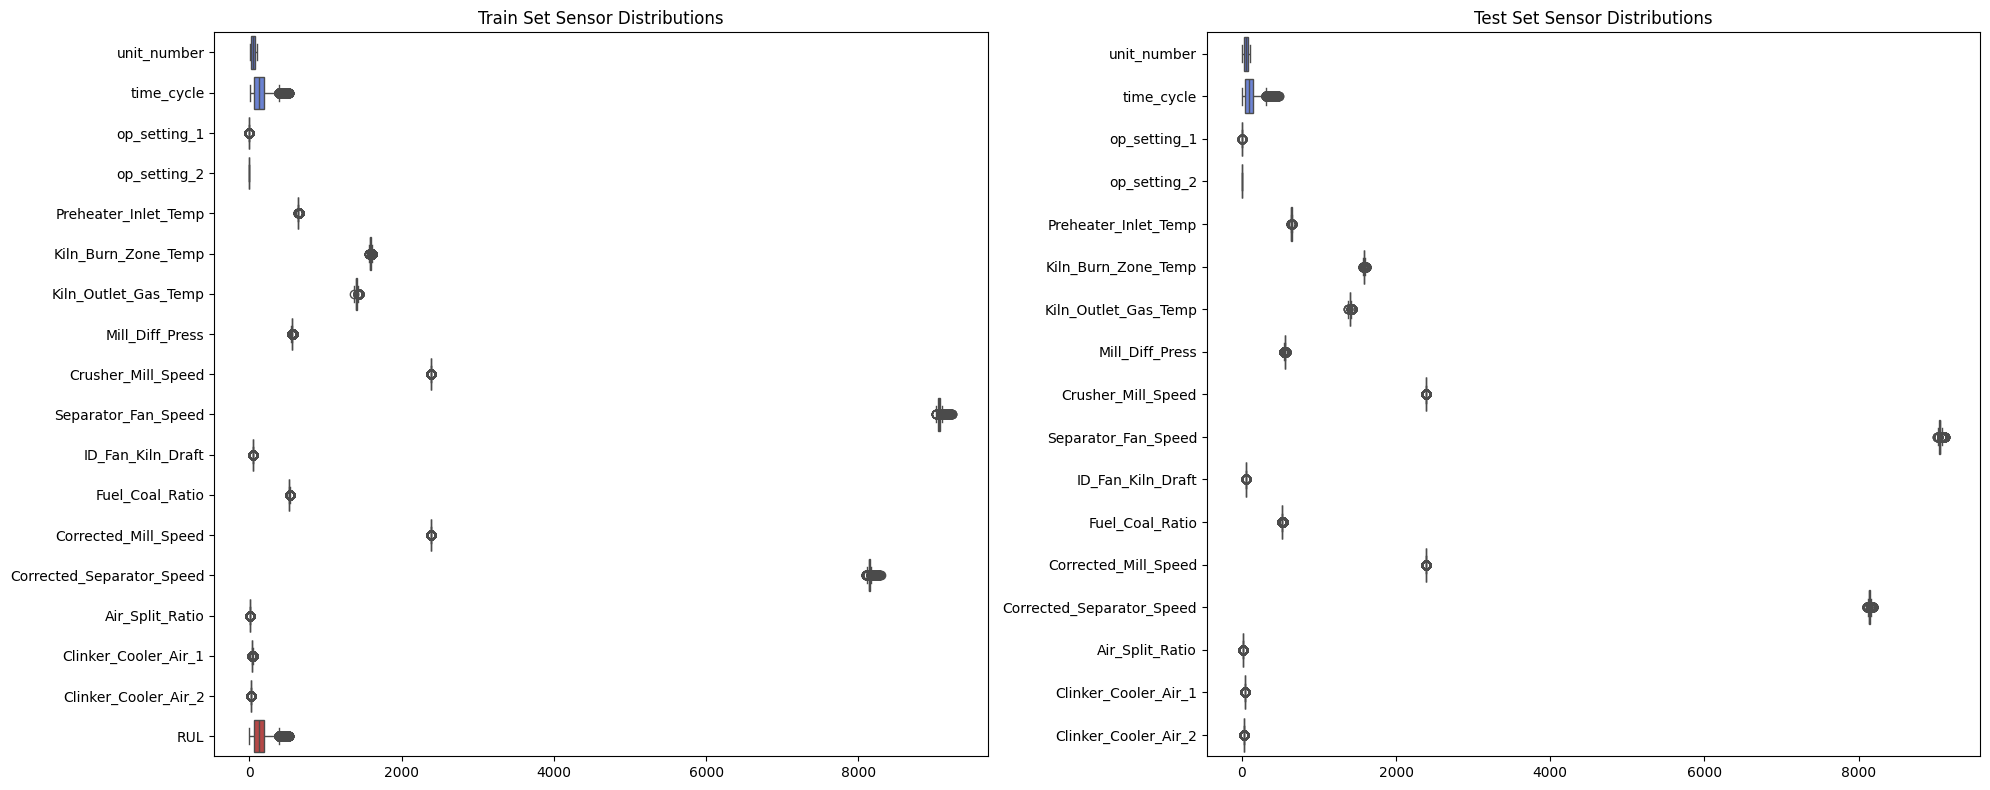

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.boxplot(data=train_df, ax=axes[0], orient="h", palette="coolwarm")
axes[0].set_title("Train Set Sensor Distributions")
sns.boxplot(data=test_df, ax=axes[1], orient="h", palette="coolwarm")
axes[1].set_title("Test Set Sensor Distributions")
plt.tight_layout()
plt.show()

The outliers are negligible, so let's scale the data

In [20]:
SENSOR_COLS.extend(feature_cols)

In [21]:
SENSOR_COLS

['Preheater_Inlet_Temp',
 'Kiln_Burn_Zone_Temp',
 'Kiln_Outlet_Gas_Temp',
 'Mill_Diff_Press',
 'Crusher_Mill_Speed',
 'Separator_Fan_Speed',
 'ID_Fan_Kiln_Draft',
 'Fuel_Coal_Ratio',
 'Corrected_Mill_Speed',
 'Corrected_Separator_Speed',
 'Air_Split_Ratio',
 'Clinker_Cooler_Air_1',
 'Clinker_Cooler_Air_2',
 'Preheater_Inlet_Temp_rolling_mean',
 'Preheater_Inlet_Temp_rolling_std',
 'Preheater_Inlet_Temp_dev_from_baseline',
 'Kiln_Burn_Zone_Temp_rolling_mean',
 'Kiln_Burn_Zone_Temp_rolling_std',
 'Kiln_Burn_Zone_Temp_dev_from_baseline',
 'Kiln_Outlet_Gas_Temp_rolling_mean',
 'Kiln_Outlet_Gas_Temp_rolling_std',
 'Kiln_Outlet_Gas_Temp_dev_from_baseline',
 'Mill_Diff_Press_rolling_mean',
 'Mill_Diff_Press_rolling_std',
 'Mill_Diff_Press_dev_from_baseline',
 'Crusher_Mill_Speed_rolling_mean',
 'Crusher_Mill_Speed_rolling_std',
 'Crusher_Mill_Speed_dev_from_baseline',
 'Separator_Fan_Speed_rolling_mean',
 'Separator_Fan_Speed_rolling_std',
 'Separator_Fan_Speed_dev_from_baseline',
 'ID_Fan_Ki

In [22]:
len(SENSOR_COLS)

52

In [23]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
train_feat_scaled = scaler.fit_transform(train_feat[SENSOR_COLS])
test_feat_scaled = scaler.transform(test_feat[SENSOR_COLS])

In [24]:
train_feat_scaled_df = pd.DataFrame(train_feat_scaled, columns=SENSOR_COLS)
test_feat_scaled_df = pd.DataFrame(test_feat_scaled, columns=SENSOR_COLS)

In [ ]:
train_feat_scaled_df.head()

,Preheater_Inlet_Temp,Kiln_Burn_Zone_Temp,Kiln_Outlet_Gas_Temp,Mill_Diff_Press,Crusher_Mill_Speed,Separator_Fan_Speed,ID_Fan_Kiln_Draft,Fuel_Coal_Ratio,Corrected_Mill_Speed,Corrected_Separator_Speed,...,Corrected_Separator_Speed_dev_from_baseline,Air_Split_Ratio_rolling_mean,Air_Split_Ratio_rolling_std,Air_Split_Ratio_dev_from_baseline,Clinker_Cooler_Air_1_rolling_mean,Clinker_Cooler_Air_1_rolling_std,Clinker_Cooler_Air_1_dev_from_baseline,Clinker_Cooler_Air_2_rolling_mean,Clinker_Cooler_Air_2_rolling_std,Clinker_Cooler_Air_2_dev_from_baseline
0,-0.056338,-0.469751,-0.452563,-0.027304,-0.785714,0.118861,-0.146341,0.122677,-0.461538,0.279891,...,-0.574900,0.404659,-1.257238,0.374121,0.456204,-0.420031,0.394958,-0.229614,0.469361,-0.236952
1,0.140845,-0.309882,-0.448835,0.170648,-0.500000,0.097400,-0.317073,0.163569,-0.307692,0.791440,...,0.056149,0.520403,-1.257238,0.668542,0.237226,-0.420031,-0.109244,0.062066,0.469361,0.418651
2,-0.309859,-0.566110,0.201305,0.129693,-0.285714,0.562388,-0.341463,0.018587,-0.538462,0.609375,...,-0.168448,0.312261,0.915730,-0.272855,-0.006083,0.968297,-0.697479,-0.008255,-0.339901,-0.146239
3,0.732394,-0.209143,-0.793290,0.395904,-0.500000,0.250929,-0.292683,0.189591,0.076923,0.364130,...,-0.470983,0.199712,0.953992,-0.315987,-0.027372,0.255652,-0.235294,-0.153178,0.264533,-0.639659
4,-1.014085,0.121544,-0.392171,0.235495,-0.214286,0.887605,-0.512195,0.223048,-0.307692,0.448370,...,-0.367065,0.129529,0.792914,-0.332865,0.091241,0.586771,0.521008,-0.040542,0.532321,0.481875


In [25]:
train_feat_scaled_df = pd.concat([
    train_feat[['unit_number', 'time_cycle', 'op_setting_1', 'op_setting_2', 'RUL']],
    train_feat_scaled_df
], axis=1)

test_feat_scaled_df = pd.concat([
    test_feat[['unit_number', 'time_cycle', 'op_setting_1', 'op_setting_2']],
    test_feat_scaled_df
], axis=1)


### Lets split the data into training and test sets


In [26]:
x_train = train_feat_scaled_df.drop("RUL", axis=1)
y_train = train_feat_scaled_df["RUL"]

In [27]:
rul_df = pd.read_csv("/content/drive/MyDrive/NASA Turbofan Predictive Maintenance/RUL_FD003.csv")

In [28]:
rul_df["RUL"].max()

145

In [29]:
# generate column max for test data
rul = pd.DataFrame(test_feat_scaled_df.groupby('unit_number')['time_cycle'].max()).reset_index()
rul.columns = ['unit_number', 'max']
rul_df.columns = ['more']
rul_df['unit_number'] = rul_df.index + 1
rul_df['max'] = rul['max'] + rul_df['more']
rul_df.drop('more', axis=1, inplace=True)

In [30]:
# generate RUL for test data
test_feat_scaled_df = test_feat_scaled_df.merge(rul_df, on=['unit_number'], how='left')
test_feat_scaled_df['RUL'] = test_feat_scaled_df['max'] - test_feat_scaled_df['time_cycle']
test_feat_scaled_df.drop('max', axis=1, inplace=True)
test_feat_scaled_df.head()

,unit_number,time_cycle,op_setting_1,op_setting_2,Preheater_Inlet_Temp,Kiln_Burn_Zone_Temp,Kiln_Outlet_Gas_Temp,Mill_Diff_Press,Crusher_Mill_Speed,Separator_Fan_Speed,...,Air_Split_Ratio_rolling_mean,Air_Split_Ratio_rolling_std,Air_Split_Ratio_dev_from_baseline,Clinker_Cooler_Air_1_rolling_mean,Clinker_Cooler_Air_1_rolling_std,Clinker_Cooler_Air_1_dev_from_baseline,Clinker_Cooler_Air_2_rolling_mean,Clinker_Cooler_Air_2_rolling_std,Clinker_Cooler_Air_2_dev_from_baseline,RUL
0,1,1,-0.0017,-0.0004,-0.647887,-0.612100,-0.445853,0.174061,-1.000000,-0.625120,...,-0.311917,0.271015,-0.137084,0.310219,-2.371483,0.042017,0.339683,-1.762781,-0.012232,276
1,1,2,0.0006,-0.0002,-0.535211,-0.291267,-0.298975,0.017065,-0.928571,-0.741780,...,-0.089277,0.271015,0.429255,0.255474,-2.371483,-0.084034,0.443330,-1.762781,0.220733,275
2,1,3,0.0014,-0.0003,-1.014085,-0.628525,-0.819385,0.122867,-0.714286,-0.280094,...,-0.265227,0.903406,-0.525270,0.310219,-2.102044,0.168067,0.363123,-1.538261,-0.166168,274
3,1,4,0.0027,0.0001,-0.281690,-0.327402,-0.564399,0.180887,-0.928571,-0.273490,...,-0.295698,0.263608,-0.232724,0.218978,-1.314662,-0.378151,0.405265,-1.610529,0.203553,273
4,1,5,-0.0001,0.0001,0.084507,0.165344,-0.525629,0.037543,-0.428571,-0.628422,...,-0.185116,0.804446,0.586779,0.251825,-1.419786,0.126050,0.328798,-1.124020,-0.368209,272


In [31]:
x_test = test_feat_scaled_df.drop("RUL", axis=1)
y_test = test_feat_scaled_df["RUL"]

In [32]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((24720, 56), (24720,), (16596, 56), (16596,))

#### Cap the model at 160 so that our model learns from the point that the model starts failing

#### Experiment with using train and val split

In [33]:
# Split by asset (not by row) to avoid leakage between train/validation
from sklearn.model_selection import train_test_split
units = train_feat_scaled_df['unit_number'].unique()
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

# SENSOR_COLS already contains the original and rolling sensor features
feature_cols_for_model = ['unit_number', 'time_cycle', 'op_setting_1', 'op_setting_2'] + SENSOR_COLS

X_train = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(train_units)][feature_cols_for_model]
y_train = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(train_units)]['RUL']
X_val = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(val_units)][feature_cols_for_model]
y_val = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(val_units)]['RUL']

CAP = 150
y_train_capped = y_train.clip(upper=CAP)
y_val_capped = y_val.clip(upper=CAP)

## BEGIN MODELLING WITH LSTM

### Preparing Data for LSTM

LSTMs require input data in a sequential format. We will create sequences of sensor readings and operational settings for each unit. For each sequence, the target (output) will be the RUL of the last time step in that sequence. This is done using a sliding window approach.

We will use a `SEQUENCE_LENGTH` of 50, meaning each input sample to the LSTM will consist of 50 consecutive time steps (cycles) for a given engine. The features for the LSTM will include the operational settings (`op_setting_1`, `op_setting_2`) and all the `SENSOR_COLS` (which would not include original, rolling mean, rolling std, and deviation from baseline features ecause the LSTM has a rolling window already).

In [34]:
SEQUENCE_LENGTH = 50

# Define the features that will be used for the LSTM model
# Exclude 'unit_number' and 'time_cycle' as they are identifiers, not direct features for the LSTM
feature_cols_lstm = ['op_setting_1', 'op_setting_2'] + SENSOR_COLS

def create_sequences(df, rul_series, sequence_length, feature_columns, units):
    X, y = [], []
    for unit_num in units:
        unit_df = df[df['unit_number'] == unit_num]
        unit_rul = rul_series[df['unit_number'] == unit_num]

        # Ensure we have enough data points to create at least one sequence
        if len(unit_df) >= sequence_length:
            for i in range(len(unit_df) - sequence_length + 1):
                # Extract sequence of features
                X.append(unit_df[feature_columns].iloc[i:i + sequence_length].values)
                # The RUL for the sequence is the RUL of the last time step in the sequence
                y.append(unit_rul.iloc[i + sequence_length - 1])
    return np.array(X), np.array(y)

# Create sequences for training data
X_train_lstm, y_train_lstm = create_sequences(
    df=X_train,
    rul_series=y_train_capped,
    sequence_length=SEQUENCE_LENGTH,
    feature_columns=feature_cols_lstm,
    units=train_units
)

# Create sequences for validation data
X_val_lstm, y_val_lstm = create_sequences(
    df=X_val,
    rul_series=y_val_capped,
    sequence_length=SEQUENCE_LENGTH,
    feature_columns=feature_cols_lstm,
    units=val_units
)

# For the test set, we only predict the RUL for the *last* sequence of each unit.
# This means for each test unit, we take its last 'SEQUENCE_LENGTH' cycles to form the input X.
# The y_test_lstm will correspond to the RUL of the last cycle of each test unit.

X_test_lstm = []
y_test_lstm = []

# Collect actual RUL values for the last cycle of each test unit for comparison
final_rul_test_units = y_test.groupby(x_test['unit_number']).last().clip(upper=CAP)

for unit_num in x_test['unit_number'].unique():
    unit_df_test = x_test[x_test['unit_number'] == unit_num]

    # Ensure we have enough data points to create the last sequence
    if len(unit_df_test) >= SEQUENCE_LENGTH:
        X_test_lstm.append(unit_df_test[feature_cols_lstm].iloc[-SEQUENCE_LENGTH:].values)
        # The target for the test set is the actual RUL of the last time cycle of that unit, capped
        y_test_lstm.append(final_rul_test_units[unit_num])

X_test_lstm = np.array(X_test_lstm)
y_test_lstm = np.array(y_test_lstm)

In [35]:
print(f"Shape of X_train_lstm: {X_train_lstm.shape}")
print(f"Shape of y_train_lstm: {y_train_lstm.shape}")
print(f"Shape of X_val_lstm: {X_val_lstm.shape}")
print(f"Shape of y_val_lstm: {y_val_lstm.shape}")
print(f"Shape of X_test_lstm: {X_test_lstm.shape}")
print(f"Shape of y_test_lstm: {y_test_lstm.shape}")

Shape of X_train_lstm: (16092, 50, 54)
Shape of y_train_lstm: (16092,)
Shape of X_val_lstm: (3728, 50, 54)
Shape of y_val_lstm: (3728,)
Shape of X_test_lstm: (97, 50, 54)
Shape of y_test_lstm: (97,)


In [67]:
# Build model
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(SEQUENCE_LENGTH, len(feature_cols_lstm))),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 64)             │        30,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,577 (127.25 KB)

 Trainable params: 32,577 (127.25 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# fit the model
tf.random.set_seed(42)
model_history = model.fit(X_train_lstm,
                          y_train_lstm,
                          epochs=10,
                          validation_data=(X_val_lstm, y_val_lstm),
                          batch_size=32,
                          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3),
                                     tf.keras.callbacks.ModelCheckpoint(filepath="model.weights.h5",
                                                                        save_weights_only=True,
                                                                        save_best_only=True)])

Epoch 1/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 414.7274 - mean_absolute_error: 14.8856 - val_loss: 410.7432 - val_mean_absolute_error: 14.5798
Epoch 2/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 385.6262 - mean_absolute_error: 14.2902 - val_loss: 372.2285 - val_mean_absolute_error: 13.5509
Epoch 3/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 364.4662 - mean_absolute_error: 13.9878 - val_loss: 356.8857 - val_mean_absolute_error: 14.0006
Epoch 4/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 357.1590 - mean_absolute_error: 13.8375 - val_loss: 386.3716 - val_mean_absolute_error: 13.9997
Epoch 5/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 356.7719 - mean_absolute_error: 13.7686 - val_loss: 382.7874 - val_mean_absolute_error: 14.1774
Epoch 6/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 346.0304 - mean_absolute_error: 13.5826 - val_loss: 368.3903 - val_mean_absolute_error: 13.3243


In [69]:
model.load_weights("/content/model.weights.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [111]:
y_pred = model.predict(X_test_lstm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [112]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred))
mae = mean_absolute_error(y_test_lstm, y_pred)
r2 = r2_score(y_test_lstm, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 17.80
MAE: 12.70
R²: 0.81


In [73]:
def pred_score(y_true, y_pred):
    score = 0
    for yt, yp in zip(y_true, y_pred):
        d = yp - yt
        if d < 0:
            score += np.exp(-d / 13) - 1
        else:
            score += np.exp(d / 10) - 1
    return score
pred_score(y_test_lstm, y_pred)

array([956.07868259])

## Anomaly Detection with the One-Class CNN

In [87]:
# split our train data into train and val splits
from sklearn.model_selection import train_test_split
units = train_feat_scaled_df['unit_number'].unique()
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

feature_cols = ["unit_number", 'op_setting_1', 'op_setting_2'] + SENSOR_COLS

X_train = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(train_units)][feature_cols]
y_train = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(train_units)]['RUL']
X_val = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(val_units)][feature_cols]
y_val = train_feat_scaled_df[train_feat_scaled_df['unit_number'].isin(val_units)]['RUL']
X_test = test_feat_scaled_df[feature_cols]

# Filter data to collect only those with RUL higher than CAP
# Assuming CAP is already defined (e.g., CAP=150) from previous cells.
mask_train = y_train > CAP
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_val = y_val > CAP
X_val = X_val[mask_val]
y_val = y_val[mask_val]

In [88]:
mask_test = y_test > CAP
X_test = X_test[mask_test]
y_test = y_test[mask_test]

In [89]:
SEQUENCE_LENGTH = 50

# remove unit number from the feature column
feature_cols.remove('unit_number')

def create_sequences(df, sequence_length, feature_columns, units):
    X = []
    for unit_num in units:
        unit_df = df[df['unit_number'] == unit_num]

        # Ensure we have enough data points to create at least one sequence
        if len(unit_df) >= sequence_length:
            for i in range(len(unit_df) - sequence_length + 1):
                # Extract sequence of features
                X.append(unit_df[feature_columns].iloc[i:i + sequence_length].values)
    return np.array(X)

# Create sequences for training data
X_train_cnn = create_sequences(
    df=X_train,
    sequence_length=SEQUENCE_LENGTH,
    feature_columns=feature_cols,
    units=train_units
)

# Create sequences for validation data
X_val_cnn = create_sequences(
    df=X_val,
    sequence_length=SEQUENCE_LENGTH,
    feature_columns=feature_cols,
    units=val_units
)

x_test_cnn = create_sequences(
    df=X_test,
    sequence_length=SEQUENCE_LENGTH,
    feature_columns=feature_cols,
    units=test_df['unit_number'].unique()
)

In [90]:
print("Train sequences:", X_train_cnn.shape)
print("Val sequences:", X_val_cnn.shape)
print("Test sequences:", x_test_cnn.shape)
print("Engines contributing to train:", X_train['unit_number'].nunique(), "/", len(train_units))

Train sequences: (4739, 50, 54)
Val sequences: (827, 50, 54)
Test sequences: (4939, 50, 54)
Engines contributing to train: 78 / 80


In [102]:
from tensorflow.keras import layers, models, optimizers

# Input shape
n_features = X_train_cnn.shape[2]
input_shape = (SEQUENCE_LENGTH, n_features)


encoder_input = layers.Input(shape=input_shape)

x = layers.Conv1D(32, 3, activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling1D(2, padding='same')(x)

x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)

latent_spatial_shape = x.shape[1:]

x = layers.Flatten()(x)
latent_representation = layers.Dense(32, activation='relu', name='bottleneck')(x)

x = layers.Dense(latent_spatial_shape[0] * latent_spatial_shape[1], activation='relu')(latent_representation)
x = layers.Reshape(latent_spatial_shape)(x)

x = layers.Conv1DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
x = layers.Conv1DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)

x = layers.Cropping1D((0, x.shape[1] - SEQUENCE_LENGTH))(x)

decoder_output = layers.Conv1D(n_features, 3, activation='linear', padding='same')(x)

model_2 = models.Model(inputs=encoder_input, outputs=decoder_output)
model_2.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 50, 54)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 50, 32)         │         5,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 25, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 832)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │        26,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 832)            │        27,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_4              │ (None, 26, 64)         │        12,352 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_5              │ (None, 52, 32)         │         6,176 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping1d_2 (Cropping1D)       │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 50, 54)         │         5,238 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,302 (348.84 KB)

 Trainable params: 89,302 (348.84 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
model_2.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

In [104]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import optimizers


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model_2.fit(
    X_train_cnn, X_train_cnn,
    validation_data=(X_val_cnn, X_val_cnn),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    shuffle=True,
    verbose=1
)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.1597 - mae: 0.5478 - val_loss: 0.4534 - val_mae: 0.4568 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4772 - mae: 0.4445 - val_loss: 0.3568 - val_mae: 0.3931 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3933 - mae: 0.4040 - val_loss: 0.3216 - val_mae: 0.3727 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.3575 - mae: 0.3841 - val_loss: 0.3216 - val_mae: 0.3598 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3389 - mae: 0.3676 - val_loss: 0.2814 - val_mae: 0.3442 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3130 - mae: 0.3519 - val_loss: 0.2741 - val_mae: 0.3352 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2969 - mae: 0.3365 - val_loss: 0.2702 - val_mae: 0.3312 - learning_rate: 0.0010
Epoch 

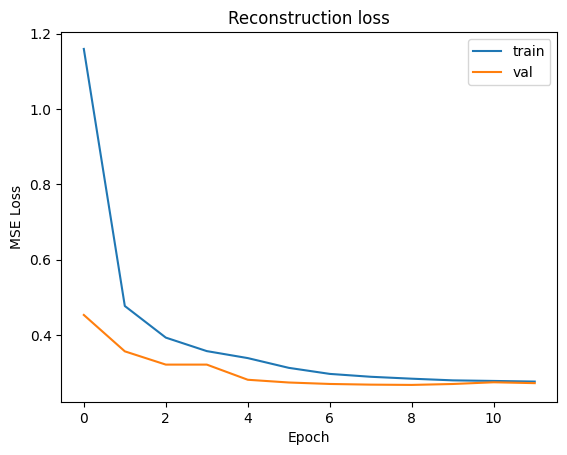

In [105]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend()
plt.title('Reconstruction loss')
plt.show()

In [106]:
import numpy as np

reconstructions = model_2.predict(x_test_cnn)
mse_per_sequence = np.mean(np.square(x_test_cnn - reconstructions), axis=(1, 2))

# A threshold (e.g. 95th/99th percentile of *normal* validation error) becomes your anomaly cutoff
threshold = np.percentile(mse_per_sequence, 95)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [107]:
threshold

np.float64(0.9024359999444219)

### Risk Scoring

In [ ]:
# normalize the values of rul_pred and mse_per_sequence
rul_pred_normalized = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())
mse_per_sequence_normalized = (mse_per_sequence - mse_per_sequence.min()) / (mse_per_sequence.max() - mse_per_sequence.min())

In [ ]:
len(rul_pred_normalized), len(mse_per_sequence_normalized)

(97, 827)

In [ ]:
# risk scoring
risk_score = 0.6 * (1 - rul_pred_normalized) + 0.4 * mse_per_sequence_normalized

In [ ]:
mse_per_sequence_normalized.shape

(827,)

In [ ]:
if risk_score < 0.3:
    status = "Healthy"
elif risk_score < 0.7:
    status = "Warning"
else:
    status = "Critical"